# Libraries

In [2]:
!pip install pywt

ERROR: Could not find a version that satisfies the requirement pywt (from versions: none)
ERROR: No matching distribution found for pywt


In [3]:
import pywt
print(pywt.__version__)  # This should print the version of PyWavelets installed


1.1.1


In [5]:
import pywt
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd

from sklearn.decomposition import IncrementalPCA

from scipy.io.wavfile import write
import scipy.io.wavfile as wavfile
import scipy.io.wavfile as wav

import scipy.linalg as la 
from scipy.signal import wiener, butter, filtfilt, correlate, find_peaks, get_window


## Cross Correlation

Set2

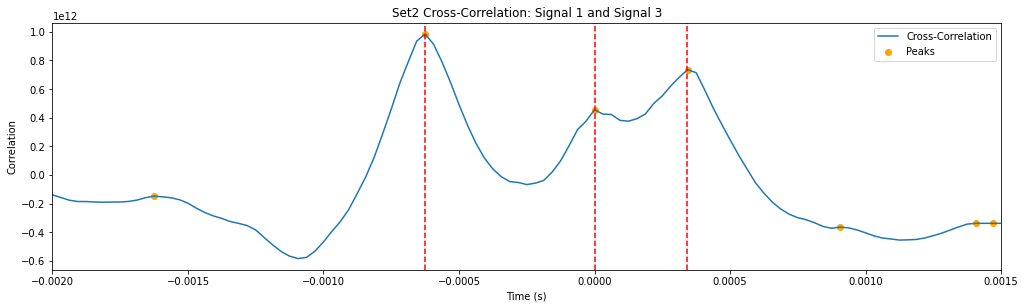

In [44]:

def calculate_tdoa_with_focus(sig1, sig2, fs, focus_samples=23):
    """Calculate TDOA with a focused range around the main correlation peak."""

    # Convert signals to float for precision in correlation
    sig1, sig2 = sig1.astype(np.float64), sig2.astype(np.float64)

    # Compute cross-correlation and lag range
    corr = correlate(sig1, sig2)
    lags = np.arange(-len(sig1) + 1, len(sig2))

    # Set ±1 ms limit around TDOA = 0
    time_limit_samples = int(1 * fs / 1000)
    limited_range = (lags >= -time_limit_samples) & (lags <= time_limit_samples)

    # Find max correlation within the limited range
    max_corr_full_idx = np.argmax(np.abs(corr[limited_range]))
    lag_full = lags[limited_range][max_corr_full_idx]

    # Set bounds for focused analysis around main peak
    start_index = max(0, lag_full - focus_samples)
    end_index = min(len(corr), lag_full + focus_samples + 1)

    # Extract focused range and find the peak in this range
    focused_corr = corr[start_index:end_index]
    focused_lags = lags[start_index:end_index]
    focused_peak_idx = np.argmax(np.abs(focused_corr))
    focused_lag = focused_lags[focused_peak_idx]

    # Convert lag indices to time for plotting
    total_lags = -lags / (fs*2)
    focused_time = focused_lags / fs

    return lag_full, corr, focused_corr, total_lags, focused_time, focused_lag

def plot_correlation(sig1, sig2, fs, pair_name):
    """Plot full and focused cross-correlation with identified peaks."""

    # Calculate TDOA and obtain correlation data
    lag_full, corr, focused_corr, total_lags, focused_time, focused_lag = calculate_tdoa_with_focus(sig1, sig2, fs)

    # Detect peaks in both the full and focused correlations
    peaks_full, w1 = find_peaks(corr)
    peak_lags_full = total_lags[peaks_full]
    peaks_focused, w2 = find_peaks(focused_corr)
    peak_lags_focused = focused_time[peaks_focused]
    # print(peaks_full, w1, peak_lags_full, w2)

    # Plot full cross-correlation
    plt.figure(figsize=(17, 10))
    plt.subplot(2, 1, 1)
    plt.title(f"Set2 Cross-Correlation: {pair_name}")
    plt.plot(total_lags, corr, label='Cross-Correlation')
    plt.scatter(peak_lags_full, corr[peaks_full], color='orange', marker='o', label='Peaks')
    # plt.axvline(x=lag_full / fs, color='r', linestyle='--', label=f'TDOA: {lag_full / fs:.6f} s')
    plt.axvline(x=-0.625/1000 , color='r', linestyle='--')
    plt.axvline(x=0.343/1000 , color='r', linestyle='--')
    plt.axvline(x=0 , color='r', linestyle='--')
    plt.xlim(-0.002, 0.0015)  # Zoom to ±1.5 milliseconds
    plt.xlabel("Time (s)")
    plt.ylabel("Correlation")
    plt.legend()

    # Plot focused cross-correlation
    # plt.subplot(2, 1, 2)
    # plt.title(f"Focused Cross-Correlation: {pair_name}")
    # plt.plot(focused_time, focused_corr, label='Focused Cross-Correlation')
    # plt.scatter(peak_lags_focused, focused_corr[peaks_focused], color='orange', marker='o', label='Peaks')
    # plt.axvline(x=focused_lag / fs, color='r', linestyle='--', label=f'Focused TDOA: {focused_lag / fs:.6f} s')
    # plt.xlim(-0.002, 0.0015)
    # plt.xlabel("Time (s)")
    # plt.ylabel("Correlation")
    # plt.legend()

    # plt.tight_layout()
    # plt.show()

    # Print TDOA information
    # print(f"Main TDOA (s): {lag_full / fs:.6f}")
    # print(f"Focused TDOA (s): {focused_lag / fs:.6f}")

# Load the audio files
fs = 16000  # Sampling rate in Hz
_, signal1 = wav.read("H:/DSP_project/mixture1_set2.wav")
_, signal2 = wav.read("H:/DSP_project/mixture2_set2.wav")
_, signal3 = wav.read("H:/DSP_project/mixture3_set2.wav")

# Plot for signal1 and signal3, change as needed for other pairs

plot_correlation(signal1, signal3, fs, "Signal 1 and Signal 3")


Set1

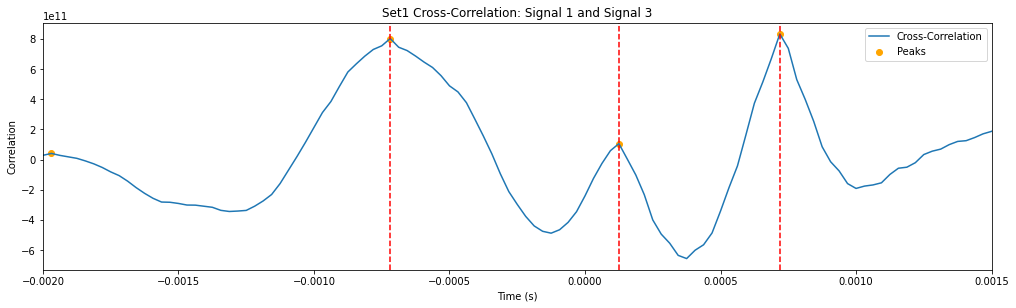

In [47]:

def calculate_tdoa_with_focus(sig1, sig2, fs, focus_samples=23):
    """Calculate TDOA with a focused range around the main correlation peak."""

    # Convert signals to float for precision in correlation
    sig1, sig2 = sig1.astype(np.float64), sig2.astype(np.float64)

    # Compute cross-correlation and lag range
    corr = correlate(sig1, sig2)
    lags = np.arange(-len(sig1) + 1, len(sig2))

    # Set ±1 ms limit around TDOA = 0
    time_limit_samples = int(1 * fs / 1000)
    limited_range = (lags >= -time_limit_samples) & (lags <= time_limit_samples)

    # Find max correlation within the limited range
    max_corr_full_idx = np.argmax(np.abs(corr[limited_range]))
    lag_full = lags[limited_range][max_corr_full_idx]

    # Set bounds for focused analysis around main peak
    start_index = max(0, lag_full - focus_samples)
    end_index = min(len(corr), lag_full + focus_samples + 1)

    # Extract focused range and find the peak in this range
    focused_corr = corr[start_index:end_index]
    focused_lags = lags[start_index:end_index]
    focused_peak_idx = np.argmax(np.abs(focused_corr))
    focused_lag = focused_lags[focused_peak_idx]

    # Convert lag indices to time for plotting
    total_lags = -lags / (fs*2)
    focused_time = focused_lags / fs

    return lag_full, corr, focused_corr, total_lags, focused_time, focused_lag

def plot_correlation(sig1, sig2, fs, pair_name):
    """Plot full and focused cross-correlation with identified peaks."""

    # Calculate TDOA and obtain correlation data
    lag_full, corr, focused_corr, total_lags, focused_time, focused_lag = calculate_tdoa_with_focus(sig1, sig2, fs)

    # Detect peaks in both the full and focused correlations
    peaks_full, w1 = find_peaks(corr)
    peak_lags_full = total_lags[peaks_full]
    peaks_focused, w2 = find_peaks(focused_corr)
    peak_lags_focused = focused_time[peaks_focused]
    # print(peaks_full, w1, peak_lags_full, w2)

    # Plot full cross-correlation
    plt.figure(figsize=(17, 10))
    plt.subplot(2, 1, 1)
    plt.title(f"Set1 Cross-Correlation: {pair_name}")
    plt.plot(total_lags, corr, label='Cross-Correlation')
    plt.scatter(peak_lags_full, corr[peaks_full], color='orange', marker='o', label='Peaks')
    # plt.axvline(x=lag_full / fs, color='r', linestyle='--', label=f'TDOA: {lag_full / fs:.6f} s')
    plt.axvline(x=-0.71875/1000 , color='r', linestyle='--')
    plt.axvline(x=0.71875/1000 , color='r', linestyle='--')
    plt.axvline(x=0.125/1000 , color='r', linestyle='--')
    plt.xlim(-0.002, 0.0015)  # Zoom to ±1.5 milliseconds
    plt.xlabel("Time (s)")
    plt.ylabel("Correlation")
    plt.legend()
    
# Load the audio files
fs = 16000  # Sampling rate in Hz
_, signal1 = wav.read("H:/DSP_project/mixture1.wav")
_, signal2 = wav.read("H:/DSP_project/mixture2.wav")
_, signal3 = wav.read("H:/DSP_project/mixture3.wav")

# Plot for signal1 and signal3, change as needed for other pairs

plot_correlation(signal1, signal3, fs, "Signal 1 and Signal 3")


# GCC Phat

To modify the gcc_phat function so that it focuses on a specific range of samples from -23.3 to +23.3 (centered around 0):

In [6]:
"""
DOA Estimation: We use the GCC-PHAT method to calculate time differences of arrival (TDOA) between microphones.
The function gcc_phat computes the cross-correlation between signals,
using phase transform for more accurate TDOA estimation.
"""


def gcc_phat(sig, refsig, fs=16000, max_tau=None):
    """ 
    Estimate the top 3 time delays of arrival (TDOAs) between sig and refsig using GCC-PHAT.
    Returns the 3 highest taus and the corresponding cross-correlation (cc).
    """
    n = sig.shape[0] + refsig.shape[0]
    SIG = np.fft.rfft(sig, n=n)
    REFSIG = np.fft.rfft(refsig, n=n)
    R = SIG * np.conj(REFSIG)
    cc = np.fft.irfft(R / np.abs(R), n=(n))
    
    # Restrict to a range of shifts
    max_shift = int(min(n / 2, max_tau * fs)) if max_tau else n // 2
    cc = np.concatenate((cc[-max_shift:], cc[:max_shift+1]))
    
    # Find the indices of the top 3 maxima of abs(cc)
    top_indices = np.argsort(np.abs(cc))[-10:][::-1]  # Sort descending and get top 3
    
    # Compute corresponding shifts and taus
    shifts = top_indices - max_shift
    taus = shifts / float(fs)
    
    return taus, cc

# Load the audio files
# fs, signal1 = wav.read("H:/DSP_project/mixture1.wav")
# _, signal2 = wav.read("H:/DSP_project/mixture2.wav")
# _, signal3 = wav.read("H:/DSP_project/mixture3.wav")

# set 2
fs, signal1 = wav.read("H:/DSP_project/mixture1_set2.wav")
_, signal2 = wav.read("H:/DSP_project/mixture2_set2.wav")
_, signal3 = wav.read("H:/DSP_project/mixture3_set2.wav")

# Perform GCC-PHAT to estimate TDOA
# tau12, cc12 = gcc_phat(signal1, signal2, fs)
tau13, cc13 = gcc_phat(signal1, signal3, fs)
# tau23, cc23 = gcc_phat(signal2, signal3, fs)

# print(f"Estimated TDOA between mic 1 and mic 2: {tau12}")
print(f"Estimated TDOA between mic 1 and mic 3: {-tau13/2}")
# print(f"Estimated TDOA between mic 2 and mic 3: {tau23}")


Estimated TDOA between mic 1 and mic 3: [-6.2500e-04  3.7500e-04 -6.5625e-04  3.4375e-04 -5.9375e-04 -0.0000e+00
  3.1250e-04  4.0625e-04 -6.2500e-05 -6.8750e-04]


### We can see the peaks  TDOA 0.343, 0.625 and 0 are in the peaks for GCC for **Set2** mixtures 

tdoa for set 1

In [9]:
# Load the audio files
# fs, signal1 = wav.read("H:/DSP_project/mixture1.wav")
# _, signal2 = wav.read("H:/DSP_project/mixture2.wav")
# _, signal3 = wav.read("H:/DSP_project/mixture3.wav")

# set 2
fs, signal1 = wav.read("H:/DSP_project/mixture1.wav")
_, signal2 = wav.read("H:/DSP_project/mixture2.wav")
_, signal3 = wav.read("H:/DSP_project/mixture3.wav")

# Perform GCC-PHAT to estimate TDOA
# tau12, cc12 = gcc_phat(signal1, signal2, fs)
tau13, cc13 = gcc_phat(signal1, signal3, fs)
# tau23, cc23 = gcc_phat(signal2, signal3, fs)

# print(f"Estimated TDOA between mic 1 and mic 2: {tau12}")
print(f"Estimated TDOA between mic 1 and mic 3: {tau13/2}")
# print(f"Estimated TDOA between mic 2 and mic 3: {tau23}")


Estimated TDOA between mic 1 and mic 3: [-7.1875e-04 -7.5000e-04  7.1875e-04 -1.2500e-04 -6.8750e-04 -2.5000e-04
 -3.7500e-04 -2.8125e-04 -9.3750e-05  6.8750e-04]


### We can see the peaks  TDOA 0.71875, -0.71875 and 0.125 are in the peaks for GCC for **Set1** mixtures 

In [10]:
# Define the constants
d = 0.5  # Distance between microphones (25 cm = 0.25 m)
c = 343.0  # Speed of sound in air (m/s)
tau_max = d / c  # Maximum possible TDOA

In [11]:
# Check if the tau values are valid before calculating DOA
def calculate_doa(tau, d, c):
    # Ensure the value is within the valid range
    if np.abs(tau) <= tau_max:
        return np.arcsin(c * tau / d) * 180 / np.pi  # Convert to degrees
    else:
        print(f"Warning: TDOA {tau:.6f} exceeds the maximum limit", d/c)
        return np.nan

# Calculate the DOA for each pair of microphones
# theta12 = calculate_doa(tau12, d, c)
theta13_1 = calculate_doa(tau13[0], d, c)
theta13_2 = calculate_doa(tau13[1], d, c)
theta13_3 = calculate_doa(tau13[2], d, c)
# theta13_4 = calculate_doa(tau13[3], d, c)
# theta13_5 = calculate_doa(tau13[4], d, c)
# theta13_6 = calculate_doa(tau13[5], d, c)
# theta13_7 = calculate_doa(tau13[6], d, c)
# theta13_8 = calculate_doa(tau13[7], d, c)
# theta13_9 = calculate_doa(tau13[8], d, c)
# theta13_10 = calculate_doa(tau13[9], d, c)
# theta23 = calculate_doa(tau23, d, c)

# Print the estimated DOA values
# print(f"Estimated DOA (theta) between mic 1 and mic 2: {theta12:.2f} degrees")
print(f"Estimated DOA (theta) between mic 1 and mic 3: {theta13_1:.2f} {theta13_2:.2f} {theta13_3:.2f} degrees")# {theta13_4:.2f} {theta13_5:.2f} {theta13_6:.2f} {theta13_7:.2f} {theta13_8:.2f}  {theta13_9:.2f} {theta13_10:.2f} degrees")
# print(f"Estimated DOA (theta) between mic 2 and mic 3: {theta23:.2f} degrees")



Estimated DOA (theta) between mic 1 and mic 3: -80.44 nan 80.44 degrees


## NP Corr

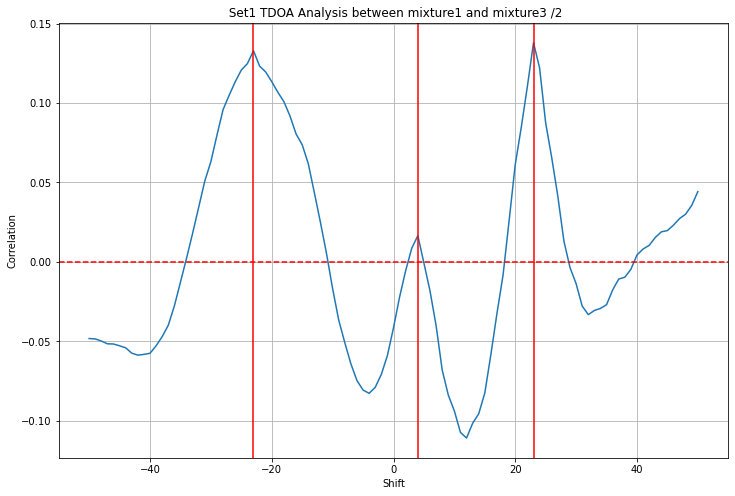

In [19]:
import numpy as np  
import matplotlib.pyplot as plt  

# Example signals for x1 and x2 (replace with actual signal data)  
fs, x1 = wav.read("H:/DSP_project/mixture1.wav")

_, x2 = wav.read("H:/DSP_project/mixture3.wav")

# Define the range of shifts to explore, e.g., from -50 to 50  
shifts = np.arange(-50, 51)  # Adjust the range as needed  
responses = []  

for shift in shifts:  
    x2_shifted = np.roll(x2, -shift)  # Shift x2  
    response = np.corrcoef(x1, x2_shifted)[0, 1]  # Compute correlation  
    responses.append(response/2)  # Store response  

# Plotting the results  
plt.figure(figsize=(12, 8))
plt.plot(shifts, responses)  
plt.xlabel('Shift')  
plt.ylabel('Correlation')  
plt.axvline(-23, color = 'red')
plt.axvline(4, color = 'red')
plt.axvline(23, color = 'red')
plt.title(' Set1 TDOA Analysis between mixture1 and mixture3 /2')  
plt.grid()  
plt.axhline(y=0, color='r', linestyle='--')  # Optional: red line at y=0 for reference  
plt.show()

In [26]:
4/(2*16000) *1000

0.125

Peaks (time in ms and correlation values):
Time: -1.4375 ms, Correlation: 0.2657
Time: 0.2500 ms, Correlation: 0.0330
Time: 1.4375 ms, Correlation: 0.2759


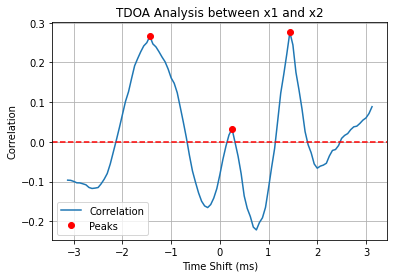

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
from scipy.signal import find_peaks

# Load example signals x1 and x2
fs, x1 = wav.read("H:/DSP_project/mixture1.wav")  # Sampling frequency and signal 1
_, x2 = wav.read("H:/DSP_project/mixture3.wav")  # Signal 2

# Define the range of shifts to explore, e.g., from -50 to 50
shifts = np.arange(-50, 51)  # Adjust the range as needed
responses = []

# Compute correlation for each shift
for shift in shifts:
    x2_shifted = np.roll(x2, -shift)  # Shift x2
    response = np.corrcoef(x1, x2_shifted)[0, 1]  # Compute correlation
    responses.append(response)  # Store response

# Convert shifts to time in milliseconds
time_shifts_ms = (shifts / fs) * 1000  # Convert to milliseconds

# Find peaks in the responses
peaks, _ = find_peaks(responses)  # Identify peaks

# Print peak time points in milliseconds and their values
print("Peaks (time in ms and correlation values):")
for peak in peaks:
    print(f"Time: {time_shifts_ms[peak]:.4f} ms, Correlation: {responses[peak]:.4f}")

# Plotting the results with peaks
plt.plot(time_shifts_ms, responses, label="Correlation")
plt.plot(time_shifts_ms[peaks], np.array(responses)[peaks], "ro", label="Peaks")  # Mark peaks
plt.xlabel('Time Shift (ms)')
plt.ylabel('Correlation')
plt.title('TDOA Analysis between x1 and x2')
plt.legend()
plt.grid()
plt.axhline(y=0, color='r', linestyle='--')  # Optional: red line at y=0 for reference
plt.show()
